# 🚀 Backtest Vectorisé : Stratégie Regime-Switching Momentum
Ce notebook contient **absolument tout le code source** (fonctions, classe, imports) pour que tu puisses le modifier et l'exécuter d'une traite sans dépendre de fichiers externes.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import yfinance as yf
import ta
import warnings
from datetime import datetime
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# 1. SETUP DE L'ENVIRONNEMENT & SPARK
# ==========================================
# Fix random seeds for reproducibility
np.random.seed(42)

# Remonter à la racine du projet de manière robuste (Ton code)
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())
load_dotenv()

try:
    from src.common.setup_spark import create_spark_session
    from config.config_spark import Paths
    print("✅ Imports locaux réussis !")
except Exception as e:
    print(f"❌ Erreur d'importation locale : {e}")
    sys.exit(1)

print("🚀 Initialisation de la Spark Session...")
spark = create_spark_session("Regime_Switching_Backtest")
print("✅ Spark Session créée avec succès.")


2026-03-29 16:53:06.079 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


✅ Imports locaux réussis !
🚀 Initialisation de la Spark Session...


26/03/29 16:53:06 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/29 16:53:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f80fd9a9-b069-46fb-8d08-4cd2bdbbc0de;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central


:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 66ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   0   ||   3   |   0   |
	---------------------------------------------------------------------
:: retrieving :: org.apache.spark#spark-submit-parent-f80fd9a9-b069-46fb-8d08-4cd2bdbbc0de
	confs: [default]
	0 artifacts copied, 3 already retrieved (0kB/3ms)
26/03/29 16:53:06 WARN NativeCodeLoader: Unable to load native-hadoo

✅ Spark Session créée avec succès.


In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import ta
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

class RegimeSwitchingMomentumBacktester:
    def __init__(self, start_date="2010-01-01", end_date=None):
        self.start_date = start_date
        self.end_date = end_date or datetime.today().strftime('%Y-%m-%d')
        
        self.etf_tickers = [
            'XLP', 'XLV', 'XLU', 'XLE', 'XLK', 'XLC', 'XLI', 'XLY', 
            'XLB', 'XLRE', 'TLT', 'IEF', 'HYG', 'GLD', 'VNQ'
        ]
        
    def get_sp500_regime(self) -> pd.DataFrame:
        print("📈 Fetching S&P 500 data for Regime Filter...")
        sp500 = yf.download('^GSPC', start=self.start_date, end=self.end_date, progress=False)
        sp500 = pd.DataFrame(sp500['Close'].resample('W-FRI').last())
        sp500.columns = ['Close']
        sp500['SMA_12'] = ta.trend.sma_indicator(sp500['Close'], window=26)
        sp500['SMA_26'] = ta.trend.sma_indicator(sp500['Close'], window=70)
        
        cond_bull = (sp500['SMA_12'] > sp500['SMA_26']) & (sp500['Close'] > sp500['SMA_26']) | (sp500['SMA_12'] < sp500['SMA_26']) & (sp500['Close'] > sp500['SMA_12'])
        sp500['Regime'] = np.where(cond_bull, 'Bull', 'Bear')
        
        sp500.index = pd.to_datetime(sp500.index).tz_localize(None).normalize()
        return sp500[['Close', 'SMA_12', 'SMA_26', 'Regime']]
        
    def get_etf_data(self) -> pd.DataFrame:
        print("🛡️ Fetching ETF data...")
        etf_data = yf.download(self.etf_tickers, start=self.start_date, end=self.end_date, progress=False)
        etf_close = etf_data['Close'].resample('W-FRI').last()
        
        df_list = []
        for ticker in self.etf_tickers:
            df = etf_close[[ticker]].dropna().rename(columns={ticker: 'Close'})
            df['Ticker'] = ticker
            
            df['SMA_12'] = ta.trend.sma_indicator(df['Close'], window=12)
            df['SMA_26'] = ta.trend.sma_indicator(df['Close'], window=26)
            df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
            df['Momentum_3M'] = df['Close'].pct_change(periods=13)
            
            df['Eligible'] = (df['SMA_12'] > df['SMA_26']) & (df['Close'] > df['SMA_26'])
            df_list.append(df.reset_index())
            
        res = pd.concat(df_list, ignore_index=True)
        res = res.rename(columns={'Date': 'date'})
        res['date'] = pd.to_datetime(res['date']).dt.tz_localize(None).dt.normalize()
        return res

    def load_and_prep_forex_data(self) -> pd.DataFrame:
        print("🌍 Fetching and Inverting Forex pairs (MAJORS + EXOTICS)...")
        
        # Ajout massif de paires Exotiques et Mineures
        fx_tickers = [
            # Majeures
            'EURUSD=X', 'JPY=X', 'GBPUSD=X', 'AUDUSD=X', 
            'USDCAD=X', 'USDCHF=X', 'NZDUSD=X',
            # Exotiques & Mineures (Fortes tendances historiques)
            'USDTRY=X', # Lira Turque (Inflation massive)
            'USDZAR=X', # Rand Sud-Africain
            'USDMXN=X', # Peso Mexicain
            'USDSEK=X', # Couronne Suédoise
            'USDNOK=X', # Couronne Norvégienne
            'USDSGD=X', # Dollar de Singapour
            'USDHKD=X', # Dollar de Hong Kong
            'USDTHB=X', # Baht Thaïlandais
            'USDPLN=X', # Zloty Polonais
            'USDHUF=X'  # Forint Hongrois
        ]
        
        raw_data = yf.download(fx_tickers, start=self.start_date, end=self.end_date, progress=False)
        
        results = []
        for ticker in fx_tickers:
            try:
                df_orig = pd.DataFrame({
                    'adjHigh': raw_data['High'][ticker],
                    'adjLow': raw_data['Low'][ticker],
                    'adjClose': raw_data['Close'][ticker]
                }).dropna()
            except KeyError:
                print(f"⚠️ Données manquantes pour {ticker}, on ignore.")
                continue
                
            # Création de la paire inversée pour le Short
            df_inv = pd.DataFrame({
                'adjHigh': 1 / df_orig['adjLow'],
                'adjLow': 1 / df_orig['adjHigh'],
                'adjClose': 1 / df_orig['adjClose']
            })
            
            for current_df, suffix in [(df_orig, ""), (df_inv, "_INV")]:
                if len(current_df) < 130: continue
                
                weekly_df = current_df.resample('W-FRI').agg({
                    'adjClose': 'last', 'adjHigh': 'max', 'adjLow': 'min'
                }).dropna()
                
                # 🐢 INDICATEURS MACRO-TENDANCE
                # Le plus haut de 6 MOIS (26 semaines) pour le Breakout
                weekly_df['Donchian_High_26W'] = weekly_df['adjHigh'].rolling(26).max().shift(1)
                
                weekly_df['SMA_12'] = weekly_df['adjClose'].rolling(12).mean()
                weekly_df['SMA_26'] = weekly_df['adjClose'].rolling(26).mean()
                weekly_df['SMA_50'] = weekly_df['adjClose'].rolling(50).mean()
                
                weekly_df['Momentum_3M'] = weekly_df['adjClose'].pct_change(periods=12)
                
                # 🟢 CONDITIONS D'ACHAT
                cond_breakout = weekly_df['adjClose'] > weekly_df['Donchian_High_26W']
                cond_trend = weekly_df['adjClose'] > weekly_df['SMA_26']
                
                weekly_df['Eligible'] = cond_breakout & cond_trend
                weekly_df['Exit_Stop'] = weekly_df['SMA_50'] 
                weekly_df['Ticker'] = ticker + suffix
                
                results.append(weekly_df.reset_index().rename(columns={'Date': 'date'}))

        if not results:
            return pd.DataFrame()

        final_df = pd.concat(results, ignore_index=True)
        final_df['date'] = pd.to_datetime(final_df['date']).dt.tz_localize(None).dt.normalize()
        return final_df.dropna()    

    def simulate_portfolio(self, sp500, etfs, stocks):
        print("⚙️ Lancement de la Simulation (TURTLE BREAKOUT FOREX LONG/SHORT)...")
        
        LEVERAGE = 1.0 
        MAX_POSITIONS = 3
        
        if not stocks.empty:
            stocks['date'] = pd.to_datetime(stocks['date']).dt.normalize()
            
        dates = sorted(stocks['date'].unique())
        if not dates: return pd.DataFrame()
        
        df_dates = pd.DataFrame({'date': dates})
        rebalance_dates_series = df_dates.groupby(df_dates['date'].dt.to_period('M'))['date'].max()
        rebalance_dates_str = set(date.strftime('%Y-%m-%d') for date in rebalance_dates_series)
        
        portfolio_allocations = {}
        current_portfolio = [] 
        trades_count = 0
        
        for d in dates:
            d_str = d.strftime('%Y-%m-%d')
            
            # --- 1. FILTRE HEBDOMADAIRE (EXIT TURTLE : Le Trailing Stop) ---
            surviving_portfolio = []
            for pos in current_portfolio:
                ticker = pos['Ticker']
                kept = True 
                
                asset_mask = (stocks['date'] == d) & (stocks['Ticker'] == ticker)
                if asset_mask.any():
                    price = stocks[asset_mask].iloc[0]['adjClose']
                    stop_price = stocks[asset_mask].iloc[0]['SMA_50'] 
                    
                    # 🔴 RÈGLE DE SORTIE TURTLE : Si le prix casse le plus bas de 4 semaines, on coupe.
                    if price < stop_price: 
                        kept = False 
                        
                if kept: surviving_portfolio.append(pos)
                    
            current_portfolio = surviving_portfolio

            # --- 2. RECHERCHE DE NOUVEAUX BREAKOUTS (Fin de mois) ---
            if d_str in rebalance_dates_str:
                daily_stocks = stocks[stocks['date'] == d].copy()
                
                if not daily_stocks.empty:
                    current_tickers = [p['Ticker'] for p in current_portfolio]
                    places_libres = MAX_POSITIONS - len(current_portfolio)
                    
                    if places_libres > 0:
                        # On cherche les devises en état de "Breakout" (Eligible = True)
                        eligible_stocks = daily_stocks[daily_stocks['Eligible']]
                        candidates = eligible_stocks[~eligible_stocks['Ticker'].isin(current_tickers)]
                        
                        # S'il y a trop de cassures simultanées, on prend celles avec le Momentum le plus fort
                        if not candidates.empty:
                            top_new = candidates.nlargest(places_libres, 'Momentum_3M') 
                            for _, row in top_new.iterrows():
                                current_portfolio.append({'Ticker': row['Ticker'], 'Weight': 0.0, 'Type': 'Forex'})
                                trades_count += 1
                                
                    # --- Pondération Dynamique ---
                    n_assets = len(current_portfolio)
                    if n_assets > 0:
                        dyn_weight = LEVERAGE / n_assets
                        for pos in current_portfolio: pos['Weight'] = dyn_weight
            
            # --- 3. ENREGISTREMENT ---
            current_target = {pos['Ticker']: pos['Weight'] for pos in current_portfolio}
            portfolio_allocations[d] = current_target
            
        print(f"✅ Backtest Turtle terminé. Total de trades exécutés : {trades_count}")
        return pd.DataFrame(portfolio_allocations).T.fillna(0)

In [5]:
# --- EXECUTION DU BACKTEST ---
backtester = RegimeSwitchingMomentumBacktester(start_date="1900-01-01")

print("1. Calcul du Regime de Marché...")
sp500 = backtester.get_sp500_regime()

print("2. Calcul des indicateurs ETFs...")
etfs = backtester.get_etf_data()

print("3. Chargement et traitement des 3.8M de lignes Actions (Daily -> Weekly)...")
stocks = backtester.load_and_prep_forex_data()

print("4. Simulation du portefeuille (Vectorisation)...")
allocations = backtester.simulate_portfolio(sp500, etfs, stocks)

print("Aperçu des pondérations cibles du portefeuille (Dernières semaines) :")
display(allocations.tail())


1. Calcul du Regime de Marché...
📈 Fetching S&P 500 data for Regime Filter...
2. Calcul des indicateurs ETFs...
🛡️ Fetching ETF data...
3. Chargement et traitement des 3.8M de lignes Actions (Daily -> Weekly)...
🌍 Fetching and Inverting Forex pairs (MAJORS + EXOTICS)...
4. Simulation du portefeuille (Vectorisation)...
⚙️ Lancement de la Simulation (TURTLE BREAKOUT FOREX LONG/SHORT)...
✅ Backtest Turtle terminé. Total de trades exécutés : 84
Aperçu des pondérations cibles du portefeuille (Dernières semaines) :


,JPY=X,JPY=X_INV,USDNOK=X_INV,USDSEK=X_INV,USDCAD=X_INV,USDZAR=X,USDHUF=X,USDSEK=X,USDTHB=X_INV,USDHKD=X,USDPLN=X_INV,USDCHF=X_INV,AUDUSD=X_INV,GBPUSD=X_INV,USDTHB=X,USDZAR=X_INV,NZDUSD=X,AUDUSD=X,USDCHF=X,USDHUF=X_INV,USDTRY=X,USDCAD=X,GBPUSD=X,EURUSD=X_INV,USDPLN=X,NZDUSD=X_INV,EURUSD=X,USDMXN=X_INV
2026-02-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.000000,0.333333,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.000000,0.333333,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.000000,0.333333,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.333333,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# 1. On "empile" le tableau pour avoir une série (Date / Ticker / Poids)
positions_actives = allocations.stack()

# 2. On filtre pour ne garder QUE les poids strictement supérieurs à zéro
positions_actives = positions_actives[positions_actives > 0].reset_index()

# 3. On renomme les colonnes pour faire propre
positions_actives.columns = ['Date', 'Ticker', 'Poids_Cible']

# Affichage du journal des trades
print(f"🔎 Le robot a détenu {len(positions_actives)} positions actives sur toute la période.")
display(positions_actives.tail(20)) # Affiche les 20 derniers investissements

🔎 Le robot a détenu 3311 positions actives sur toute la période.


,Date,Ticker,Poids_Cible
3291,2026-02-13,USDTHB=X_INV,0.333333
3292,2026-02-13,USDZAR=X_INV,0.333333
3293,2026-02-13,USDTRY=X,0.333333
3294,2026-02-20,USDTHB=X_INV,0.333333
3295,2026-02-20,USDZAR=X_INV,0.333333
3296,2026-02-20,USDTRY=X,0.333333
3297,2026-02-27,USDTHB=X_INV,0.333333
3298,2026-02-27,USDZAR=X_INV,0.333333
3299,2026-02-27,USDTRY=X,0.333333
3300,2026-03-06,USDTHB=X_INV,0.333333


📊 Calcul des rendements nets (Frais + Coût de la Marge déduits)...


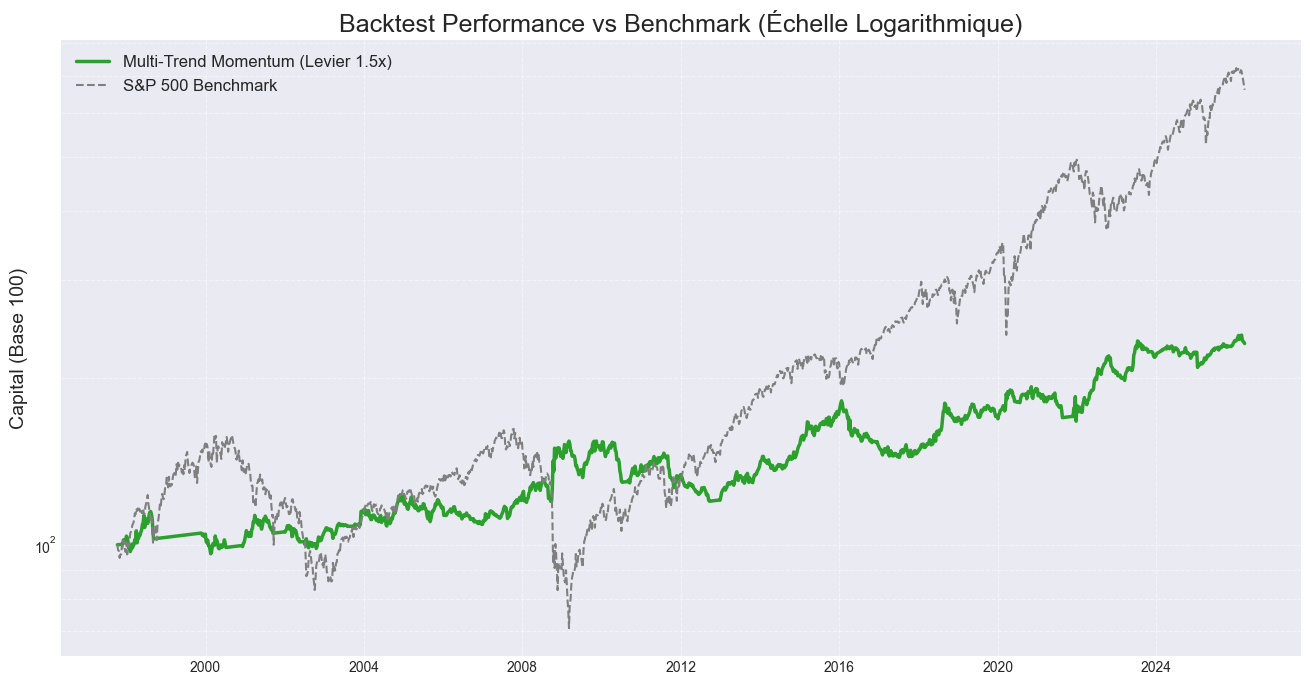

💰 Turnover moyen hebdomadaire : 6.12%
📈 Exposition moyenne au marché : 86.87%
📊 CAGR Net: 2.98% | Sharpe Net: 0.14 | Max DD: -22.11%


In [7]:
import matplotlib.pyplot as plt

# --- PARAMÈTRES FINANCIERS RÉALISTES ---
TRANSACTION_FEE = 0.001       # 0.1% de frais par transaction
CASH_YIELD_ANNUAL = 0.02      # 2% d'intérêts gagnés sur le cash (si non investi)
MARGIN_RATE_ANNUAL = 0.06     # 6% d'intérêts payés au courtier pour l'argent emprunté (Levier)

CASH_YIELD_WEEKLY = CASH_YIELD_ANNUAL / 52
MARGIN_RATE_WEEKLY = MARGIN_RATE_ANNUAL / 52

print("📊 Calcul des rendements nets (Frais + Coût de la Marge déduits)...")

# Préparation des prix
etf_prices = etfs.pivot(index='date', columns='Ticker', values='Close')
stock_prices = stocks.pivot(index='date', columns='Ticker', values='adjClose') if not stocks.empty else pd.DataFrame()
all_prices = pd.concat([etf_prices, stock_prices], axis=1).ffill()
weekly_asset_returns = all_prices.pct_change()

# Alignement des poids cibles (Décalage d'une semaine)
allocations_shifted = allocations.shift(1).fillna(0)
common_dates = allocations_shifted.index.intersection(weekly_asset_returns.index)

allocations_aligned = allocations_shifted.loc[common_dates]
returns_aligned = weekly_asset_returns.loc[common_dates, allocations_aligned.columns].fillna(0)

# --- 1. CALCUL DES EXPOSITIONS ---
invested_weight = allocations_aligned.sum(axis=1)

# Si on est investi à moins de 100%, on a du cash qui rapporte
cash_weight = (1.0 - invested_weight).clip(lower=0)

# Si on est investi à plus de 100%, on a de la dette qui coûte de l'argent
borrowed_weight = (invested_weight - 1.0).clip(lower=0)

# --- 2. RENDEMENTS ET COÛTS ---
asset_return = (allocations_aligned * returns_aligned).sum(axis=1)
cash_return = cash_weight * CASH_YIELD_WEEKLY
margin_cost = borrowed_weight * MARGIN_RATE_WEEKLY

turnover = allocations.loc[common_dates].diff().abs().sum(axis=1).fillna(0)
transaction_costs = turnover * TRANSACTION_FEE

# --- 3. RENDEMENT NET FINAL ---
portfolio_return_weekly_net = asset_return + cash_return - margin_cost - transaction_costs

# --- COURBES DE CAPITAL ---
equity_curve = (1 + portfolio_return_weekly_net).cumprod() * 100
sp500_returns = sp500['Close'].pct_change().loc[common_dates]
sp500_equity = (1 + sp500_returns).cumprod() * 100

# --- MÉTRIQUES ---
years = (equity_curve.index[-1] - equity_curve.index[0]).days / 365.25
cagr = ((equity_curve.iloc[-1] / 100) ** (1 / max(1e-5, years))) - 1

excess_return_weekly = portfolio_return_weekly_net.mean() - CASH_YIELD_WEEKLY
sharpe = (excess_return_weekly / portfolio_return_weekly_net.std()) * np.sqrt(52) if portfolio_return_weekly_net.std() != 0 else 0
max_dd = (equity_curve / equity_curve.cummax() - 1).min()

# --- AFFICHAGE ---
plt.figure(figsize=(16, 8))
plt.plot(equity_curve.index, equity_curve.values, label='Multi-Trend Momentum (Levier 1.5x)', color='#2ca02c', linewidth=2.5)
plt.plot(sp500_equity.index, sp500_equity.values, label='S&P 500 Benchmark', color='#7f7f7f', linestyle='--', linewidth=1.5)
plt.title('Backtest Performance vs Benchmark (Échelle Logarithmique)', fontsize=18)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.ylabel('Capital (Base 100)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

print(f"💰 Turnover moyen hebdomadaire : {turnover.mean()*100:.2f}%")
print(f"📈 Exposition moyenne au marché : {invested_weight.mean()*100:.2f}%")
print(f"📊 CAGR Net: {cagr*100:.2f}% | Sharpe Net: {sharpe:.2f} | Max DD: {max_dd*100:.2f}%")

📊 Calcul des rendements nets avec CARRY TRADE...


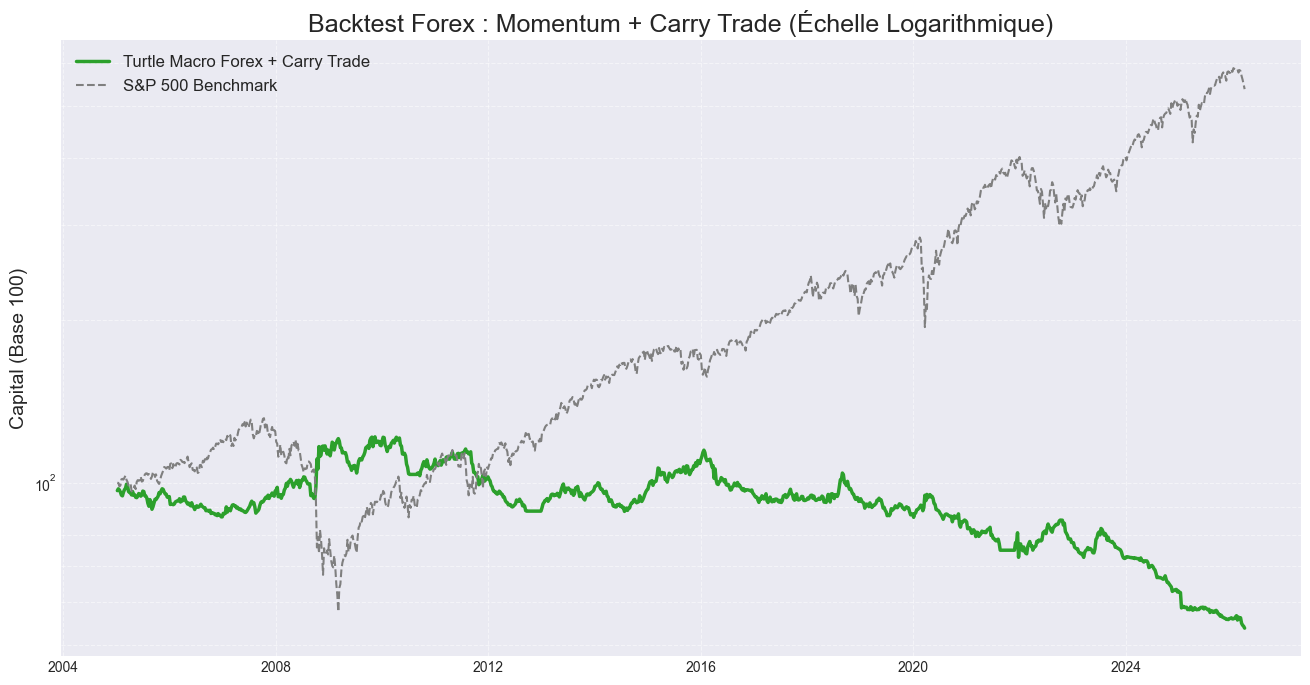

📊 CAGR Net: -2.89% | Sharpe Net: -0.24 | Max DD: -55.83%
💵 Note: Le calcul inclut un Carry Trade simulé sur la base des taux d'intérêt actuels.


26/03/29 18:11:45 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. MATRICE DES TAUX D'INTÉRÊT (Approximation pour le test) ---
# Taux annuels fictifs mais représentatifs des dynamiques (Ex: TRY et MXN très hauts, JPY et CHF très bas)
CENTRAL_BANK_RATES = {
    'USD': 0.0525,  # 5.25%
    'EUR': 0.0400,  # 4.00%
    'GBP': 0.0525,
    'JPY': 0.0010,  # 0.10% (Taux bas)
    'CHF': 0.0150,  # 1.50% (Taux bas)
    'CAD': 0.0500,
    'AUD': 0.0435,
    'NZD': 0.0550,
    'TRY': 0.4500,  # 45% (Hyperinflation turque)
    'ZAR': 0.0825,  # 8.25% (Afrique du Sud)
    'MXN': 0.1100,  # 11% (Mexique)
    'SEK': 0.0400,
    'NOK': 0.0450,
    'SGD': 0.0350,
    'HKD': 0.0550,
    'THB': 0.0250,
    'PLN': 0.0575,
    'HUF': 0.0900
}

def get_carry_yield(ticker_name):
    # Exemple: 'EURUSD=X' -> Achat EUR, Vente USD -> Rendement = Taux(EUR) - Taux(USD)
    # Exemple: 'EURUSD=X_INV' -> Achat USD, Vente EUR -> Rendement = Taux(USD) - Taux(EUR)
    
    clean_name = ticker_name.replace('=X', '')
    is_inverse = '_INV' in clean_name
    clean_name = clean_name.replace('_INV', '')
    
    if len(clean_name) == 6:
        base_ccy = clean_name[0:3]
        quote_ccy = clean_name[3:6]
        
        rate_base = CENTRAL_BANK_RATES.get(base_ccy, 0.0)
        rate_quote = CENTRAL_BANK_RATES.get(quote_ccy, 0.0)
        
        # En Forex : Long = Acheter la Base, Vendre la Quote
        if not is_inverse:
            annual_yield = rate_base - rate_quote
        else:
            annual_yield = rate_quote - rate_base
            
        return annual_yield / 52.0 # Rendement hebdomadaire
    return 0.0

print("📊 Calcul des rendements nets avec CARRY TRADE...")

# --- 2. PRÉPARATION DES PRIX ET RENDEMENTS ---
stock_prices = stocks.pivot(index='date', columns='Ticker', values='adjClose') if not stocks.empty else pd.DataFrame()
all_prices = stock_prices.ffill()
weekly_asset_returns = all_prices.pct_change()

allocations_shifted = allocations.shift(1).fillna(0)
common_dates = allocations_shifted.index.intersection(weekly_asset_returns.index)

# Filtre depuis 2005 (car les exotiques n'ont pas toujours d'historique avant)
common_dates = common_dates[common_dates >= pd.to_datetime("2005-01-01")]

allocations_aligned = allocations_shifted.loc[common_dates]
returns_aligned = weekly_asset_returns.loc[common_dates, allocations_aligned.columns].fillna(0)

# --- 3. CALCUL DES RENDEMENTS DU CAPITAL + CARRY ---
asset_price_return = (allocations_aligned * returns_aligned).sum(axis=1)

# On calcule la matrice des rendements de Carry
carry_matrix = pd.DataFrame(index=allocations_aligned.index, columns=allocations_aligned.columns)
for col in carry_matrix.columns:
    carry_matrix[col] = get_carry_yield(col)

# Le rendement du carry est appliqué au poids de la position
asset_carry_return = (allocations_aligned * carry_matrix).sum(axis=1)

# Rendement Total = Mouvement du Prix + Encaissement des Intérêts
portfolio_return_weekly_net = asset_price_return + asset_carry_return

# --- 4. COURBES DE CAPITAL ---
equity_curve = (1 + portfolio_return_weekly_net).cumprod() * 100
sp500_aligned = sp500[['Close']].reindex(common_dates).ffill()
sp500_returns = sp500_aligned['Close'].pct_change().fillna(0)
sp500_equity = (1 + sp500_returns).cumprod() * 100

# --- 5. MÉTRIQUES ---
years = (equity_curve.index[-1] - equity_curve.index[0]).days / 365.25
cagr = ((equity_curve.iloc[-1] / 100) ** (1 / max(1e-5, years))) - 1
sharpe = (portfolio_return_weekly_net.mean() / portfolio_return_weekly_net.std()) * np.sqrt(52) if portfolio_return_weekly_net.std() != 0 else 0
max_dd = (equity_curve / equity_curve.cummax() - 1).min()

# --- 6. GRAPHIQUE ---
plt.figure(figsize=(16, 8))
plt.plot(equity_curve.index, equity_curve.values, label='Turtle Macro Forex + Carry Trade', color='#2ca02c', linewidth=2.5)
plt.plot(sp500_equity.index, sp500_equity.values, label='S&P 500 Benchmark', color='#7f7f7f', linestyle='--', linewidth=1.5)
plt.title('Backtest Forex : Momentum + Carry Trade (Échelle Logarithmique)', fontsize=18)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.ylabel('Capital (Base 100)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

print(f"📊 CAGR Net: {cagr*100:.2f}% | Sharpe Net: {sharpe:.2f} | Max DD: {max_dd*100:.2f}%")
print(f"💵 Note: Le calcul inclut un Carry Trade simulé sur la base des taux d'intérêt actuels.")